In [1]:
%%capture
%pip install accelerate peft bitsandbytes transformers trl

In [ ]:
#!huggingface-cli login
from huggingface_hub import login
login("token")

In [3]:
import os
import torch
from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline,
    logging,
)
from peft import LoraConfig
from trl import SFTTrainer

In [4]:
# Model from Hugging Face hub
base_model = "Joseph7D/llama-2-7b-emotion-detector-v6_1"

# New instruction dataset
emotion_dataset = "Joseph7D/prompt-emotion-dataset-v2"


In [5]:
dataset = load_dataset(emotion_dataset, split='test')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/671 [00:00<?, ?B/s]

(…)-00000-of-00001-0c67affb9210ad40.parquet:   0%|          | 0.00/2.38M [00:00<?, ?B/s]

(…)-00000-of-00001-4f62525995947485.parquet:   0%|          | 0.00/300k [00:00<?, ?B/s]

(…)-00000-of-00001-99d9ca9cf25d3c0d.parquet:   0%|          | 0.00/300k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26934 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3366 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3372 [00:00<?, ? examples/s]

In [6]:
dataset

Dataset({
    features: ['text'],
    num_rows: 3366
})

In [7]:
compute_dtype = getattr(torch, "float16")

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=False,
)
# Load base model
model = AutoModelForCausalLM.from_pretrained(
    base_model,
    quantization_config=quant_config,
    device_map={"": 0}
)
model.config.use_cache = False
model.config.pretraining_tp = 1


# Load LLaMA tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/quantizers/auto.py:222: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.02G [00:00<?, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/164 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

In [8]:
!kill 26235

/bin/bash: line 1: kill: (26235) - No such process


In [9]:
logging.set_verbosity(logging.CRITICAL)

# Suprime mensajes de advertencia
logging.set_verbosity(logging.CRITICAL)

# Define el prompt con el formato adecuado
prompt = """Clasifica el siguiente texto en una de estas emociones: ira, disgusto, tristeza, alegría, miedo o neutral. Responde únicamente con la emoción correspondiente.

Texto: "Me indigna ver cómo algunas personas menosprecian los derechos humanos"
"""

# Genera el resultado usando el pipeline
pipe = pipeline(task="text-generation", model=model, tokenizer=tokenizer, max_length=200)
result = pipe(f"<s>[INST] {prompt} [/INST]")

# Muestra el resultado
print(result[0]['generated_text'])

<s>[INST] Clasifica el siguiente texto en una de estas emociones: ira, disgusto, tristeza, alegría, miedo o neutral. Responde únicamente con la emoción correspondiente.

Texto: "Me indigna ver cómo algunas personas menosprecian los derechos humanos"
 [/INST] ira 


# Validation

In [10]:
#!pip install tqdm

In [11]:
print(dataset[0])

{'text': '<s>[INST] Clasifica el siguiente texto en una de estas emociones: ira, disgusto, tristeza, alegría, miedo o neutral. Responde únicamente con la emoción correspondiente.\n\nTexto: "Y cuando juega mejor, gol cosas del fútbol" [/INST] neutral </s>'}


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import re
from tqdm import tqdm


# Separar prompt (input) y etiqueta (label) del formato instruct
def parse_sample(sample):
    text = sample["text"]  # campo 'text' del dataset
    inst_match = re.search(r"\[INST\](.*?)\[/INST\]", text, re.DOTALL)
    label_match = re.search(r"\[/INST\](.*?)</s>", text, re.DOTALL)

    if inst_match and label_match:
        input_text = inst_match.group(1).strip()
        label = label_match.group(1).strip().lower()
        return {"input": input_text, "label": label}
    else:
        return None

parsed_data = [parse_sample(s) for s in dataset if parse_sample(s)]


In [13]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. Preparar listas con datos de entrada, etiqueta real y predicha ---
texts = []        # el texto original de cada muestra
true_labels = []  # etiqueta real
pred_labels = []  # etiqueta generada

for sample in tqdm(parsed_data, desc="eval samples"):
    # parsed_data es la lista de dicts con 'input' y 'label'
    prompt = f"<s>[INST] {sample['input']} [/INST]"
    inputs = tokenizer(prompt, return_tensors="pt", return_attention_mask=True).to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=10,
            do_sample=False
        )
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    pred = decoded.split("[/INST]")[-1].strip().lower()

    texts.append(sample["input"])
    true_labels.append(sample["label"])
    pred_labels.append(pred)

# --- 2. Construir un DataFrame con los resultados ---
df = pd.DataFrame({
    "text": texts,
    "true": true_labels,
    "pred": pred_labels
})
# Añadimos una columna booleana de acierto
df["correct"] = df["true"] == df["pred"]

# --- 3. Métricas globales ---
print(classification_report(df["true"], df["pred"], digits=4))
print("Confusion matrix:\n", confusion_matrix(df["true"], df["pred"]))

# --- 4. Separar correctos e incorrectos ---
df_correct   = df[df["correct"]]
df_incorrect = df[~df["correct"]]

# Opcional: ver algunos ejemplos mal clasificados
print("\n--- Primeros 10 errores ---")
print(df_incorrect[["text","true","pred"]].head(10))

# También puedes exportarlos:
df_incorrect.to_csv("errores_test.csv", index=False)
df_correct.to_csv("aciertos_test.csv", index=False)


eval samples: 100%|██████████| 3366/3366 [42:30<00:00,  1.32it/s]

              precision    recall  f1-score   support

     alegría     0.8766    0.8610    0.8687       561
    disgusto     0.9434    0.9501    0.9467       561
         ira     0.8506    0.8324    0.8414       561
       miedo     0.9520    0.9198    0.9356       561
     neutral     0.8436    0.9037    0.8726       561
    tristeza     0.8548    0.8503    0.8525       561

    accuracy                         0.8862      3366
   macro avg     0.8868    0.8862    0.8863      3366
weighted avg     0.8868    0.8862    0.8863      3366

Confusion matrix:
 [[483   2  14   2  40  20]
 [  0 533  14   0  14   0]
 [ 15  19 467   5  23  32]
 [  8   4  14 516   1  18]
 [ 23   6  14   0 507  11]
 [ 22   1  26  19  16 477]]

--- Primeros 10 errores ---
                                                 text      true      pred
6   Clasifica el siguiente texto en una de estas e...  tristeza     miedo
8   Clasifica el siguiente texto en una de estas e...   neutral   alegría
18  Clasifica el siguien

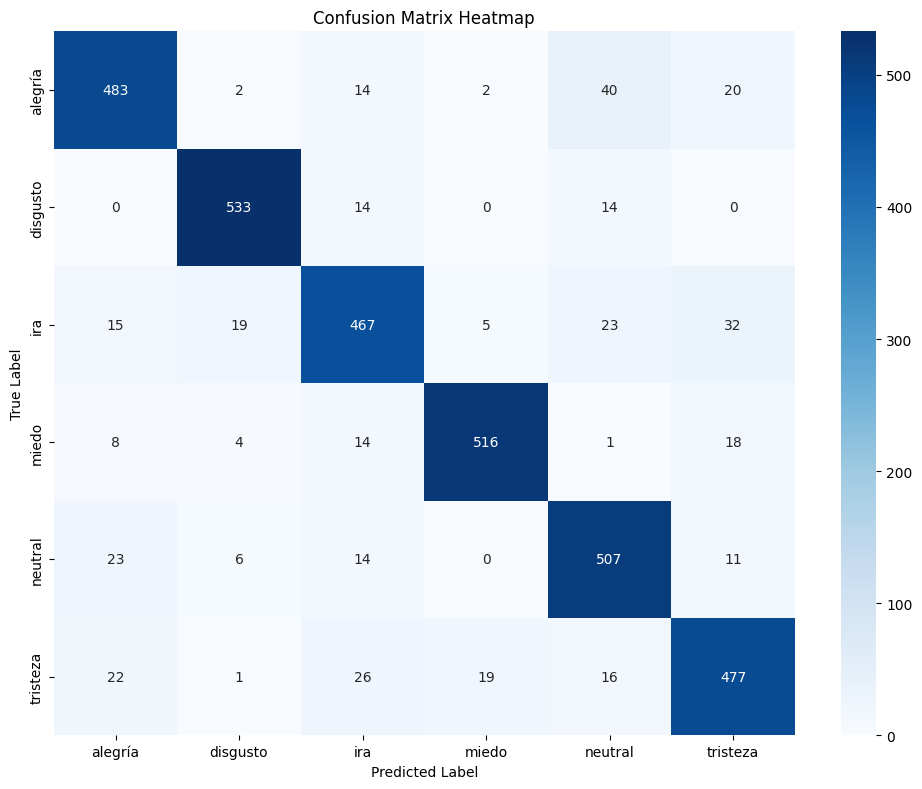

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Obtener etiquetas únicas (ordenadas por aparición en etiquetas reales)
labels = sorted(list(set(true_labels + pred_labels)))

# Matriz de confusión como array
cm = confusion_matrix(true_labels, pred_labels, labels=labels)

# Crear mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)

# Etiquetas y título
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.tight_layout()
plt.show()
